In [ ]:
from OrthoSAM import orthosam
from OrthoSAM.utility import setup, load_config, accuracy, graph_coloring
import os
from tifffile import imread, imwrite, TiffFile
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def precision_recall(AcDic):
    #threshold=0.9
    #iou = np.abs(np.array(AcDic.get('iou')))
    ac_class, count = np.unique(AcDic.get('point based'), return_counts=True)
    #TP_count = np.sum(iou >= threshold)
    TP_count = np.sum(count[ac_class > 0]) if 1 in ac_class else 0
    Label_count = AcDic.get('label_count')
    MSK_T = AcDic.get('mask_count')

    precision = TP_count / MSK_T
    recall = TP_count / Label_count
    print('Precision: ', precision)
    print('Recall: ', recall)
    #return precision, recall
from scipy.stats import ks_2samp
def ks_Dict(AcDic):
    sizes = np.sort(AcDic.get('area'))
    sizes_re = np.sort(AcDic.get('segment area'))
    ks=ks_2samp(sizes_re,sizes, method= 'exact', alternative='two-sided')
    return ks

In [3]:
mask_FH=imread('/DATA/vito/data/ImageGrains_v1_data/field_examples/FH_pred.tif')
pred_FH=np.load('/DATA/vito/output/ImageGrains_0_up2_org_b300/Merged/all_mask_merged_windows_id_001.npy')
mask_K1=imread('/DATA/vito/data/ImageGrains_v1_data/field_examples/K1_pred.tif')
pred_K1=np.load('/DATA/vito/output/ImageGrains_4_up2_org_b300/Merged/all_mask_merged_windows_id_001.npy')
mask_S1=imread('/DATA/vito/data/ImageGrains_v1_data/field_examples/S1_pred.tif')
pred_S1=np.load('/DATA/vito/output/ImageGrains_7_up2_org_b300/Merged/all_mask_merged_windows_id_001.npy')

In [5]:
AcDic_FH=accuracy(pred_FH, mask_FH)
precision_recall(AcDic_FH)
ks_Dict(AcDic_FH)
AcDic_K1=accuracy(pred_K1, mask_K1)
precision_recall(AcDic_K1)
ks_Dict(AcDic_K1)
AcDic_S1=accuracy(pred_S1, mask_S1)
precision_recall(AcDic_S1)
ks_Dict(AcDic_S1)

4453  mask(s) loaded
No. of ground truth objects: 1742
Mean mask IoU: 
0.7041949803019432
Precision:  0.3425276961338458
Recall:  0.8696900114810563
2224  mask(s) loaded
No. of ground truth objects: 1883
Mean mask IoU: 
0.75455278637876
Precision:  0.7528140477262495
Recall:  0.8879447689856612
6413  mask(s) loaded
No. of ground truth objects: 4660
Mean mask IoU: 
0.7392152933565073
Precision:  0.6624941323736504
Recall:  0.9085836909871244


KstestResult(statistic=np.float64(0.10925929905453148), pvalue=np.float64(1.8314824960542266e-28), statistic_location=np.int64(208), statistic_sign=np.int8(1))

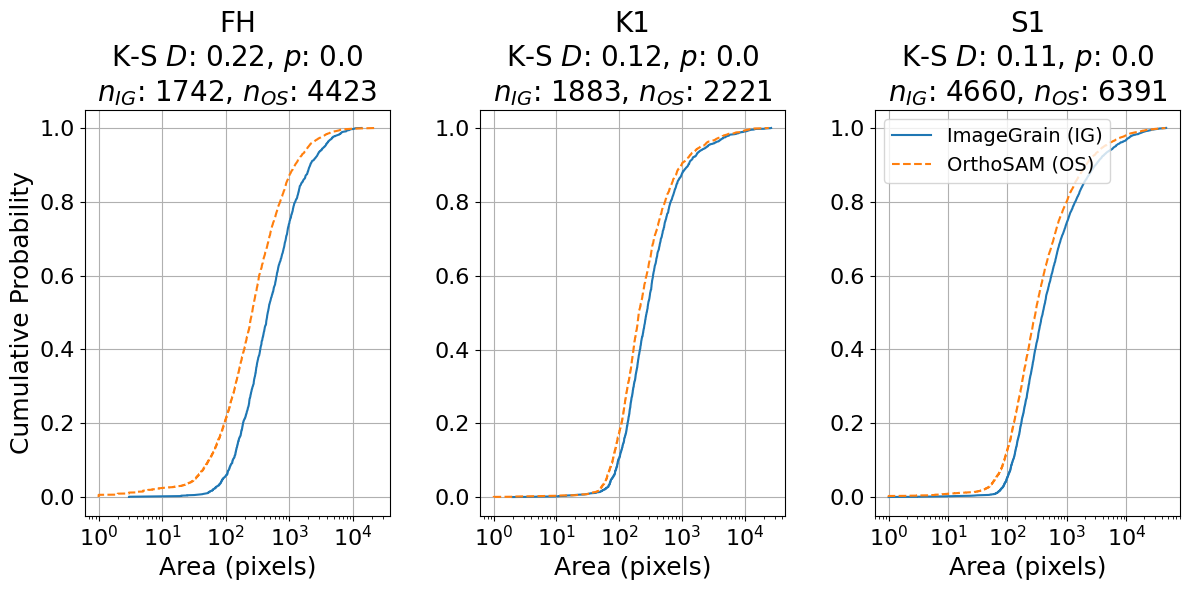

In [6]:
def cdf(AcDic, title_label):    
    sizes = np.sort(AcDic.get('area'))
    cdf = np.arange(1, len(sizes) + 1) / len(sizes)
    plt.plot(sizes, cdf, linestyle="-", label='ImageGrain (IG)')
    plt.title(title_label, fontsize=20)
    sizes_re = np.sort(AcDic.get('segment area'))
    cdf_re = np.arange(1, len(sizes_re) + 1) / len(sizes_re)
    plt.plot(sizes_re, cdf_re, linestyle="--", label='OrthoSAM (OS)')
    ks_test=ks_2samp(sizes_re,sizes, method= 'exact', alternative='two-sided')
    ac_class, count = np.unique(AcDic.get('point based'), return_counts=True)
    TP_count = np.sum(count[ac_class > 0]) if 1 in ac_class else 0
    Label_count = AcDic.get('label_count')
    MSK_T = AcDic.get('mask_count')

    precision = TP_count / MSK_T
    recall = TP_count / Label_count
    plt.title(title_label+'\n'
              +fr'K-S $D$: {np.round(ks_test[0],2):.2}, $p$: {np.round(ks_test[1],2):.2}'
              +'\n'+r'$n_{IG}$'
              +f': {len(sizes)}, '
              +r'$n_{OS}$'+f': {len(sizes_re)}'
              #+'\n'+f'P: {precision:.2}, R: {recall:.2}'
              , fontsize=20)

    plt.xscale("log")
    plt.xlabel("Area (pixels)", fontsize=18)
    plt.ylabel("Cumulative Probability", fontsize=18) 
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)       
    plt.grid(True)
plt.figure(figsize=(12, 6))
plt.subplot(1,3,1)
cdf(AcDic_FH,'FH')
plt.subplot(1,3,2)
cdf(AcDic_K1,'K1')
plt.ylabel('')
plt.subplot(1,3,3)
cdf(AcDic_S1,'S1')
plt.legend(fontsize=14)
plt.tight_layout()
plt.xlabel('Area (pixels)')
plt.ylabel('')
plt.savefig('/DATA/vito/fig/shadowed_dist.png')

In [7]:
def precision_recall_return(AcDic):
    #threshold=0.9
    #iou = np.abs(np.array(AcDic.get('iou')))
    ac_class, count = np.unique(AcDic.get('point based'), return_counts=True)
    #TP_count = np.sum(iou >= threshold)
    TP_count = np.sum(count[ac_class > 0]) if 1 in ac_class else 0
    Label_count = AcDic.get('label_count')
    MSK_T = AcDic.get('mask_count')

    precision = TP_count / MSK_T
    recall = TP_count / Label_count
    return precision, recall
import pandas as pd
import dataframe_image as dfi
#precisions=[precision_recall_return(AcDic_FH)[0],precision_recall_return(AcDic_K1)[0],precision_recall_return(AcDic_S1)[0]]
#recalls=[precision_recall_return(AcDic_FH)[1],precision_recall_return(AcDic_K1)[1],precision_recall_return(AcDic_S1)[1]]
mean_iou=[0.704, 0.754, 0.739]
mask_count=[1742, 1883, 4660]
pred_count=[4453, 2224, 6413]
df=pd.DataFrame({'Image':['FH','K1','S1']
                 #,'Precision':precisions,'Recall':recalls
                 #, 'Mean IoU':mean_iou
                 , 'OrthoSAM Prediction': pred_count, 'ImageGrain prediction': mask_count})
pd.set_option('display.float_format', '{:.3f}'.format)

dfi.export(df, "output.jpg", table_conversion="matplotlib")


In [8]:
mask_FH=imread('/DATA/vito/data/ImageGrains_v1_data/field_examples/FH_pred.tif')
import cv2
import numpy as np
img = cv2.imread('/DATA/vito/data/ImageGrains_v1_data/field_examples/FH.jpg')
img_FH = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.imread('/DATA/vito/data/ImageGrains_v1_data/field_examples/S1.jpg')
img_S1 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

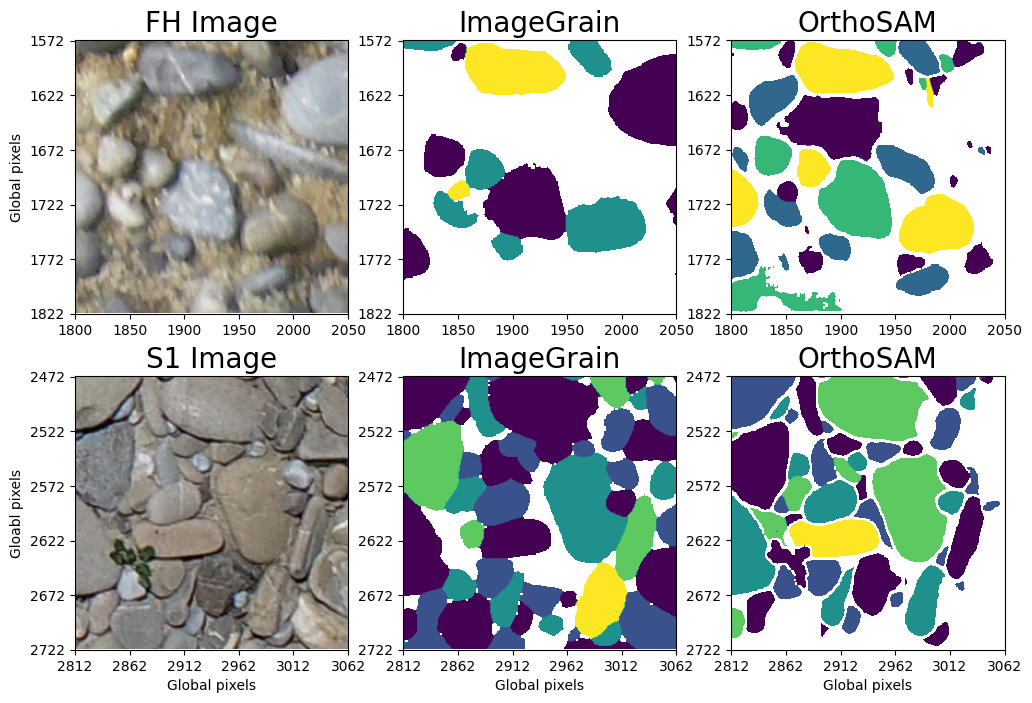

In [9]:
plt.figure(figsize=(12, 8))
plt.subplot(2,3,1)
plt.imshow(img_FH[-250:,-250:,:])
plt.title('FH Image', fontsize=20)
plt.ylabel('Global pixels')
xticks = plt.xticks()[0][1:]
yticks = plt.yticks()[0][1:]
xoffset, yoffset = img_FH.shape[0]-250, img_FH.shape[1]-250
plt.xticks(xticks, [int(x + xoffset) for x in xticks])
plt.yticks(yticks, [int(y + yoffset) for y in yticks])

plt.subplot(2,3,2)
mask_FH = mask_FH.astype("float")
mask_FH[mask_FH == 0] = np.nan
mask_FH = graph_coloring(mask_FH)
plt.imshow(mask_FH[-250:,-250:])
plt.title('ImageGrain', fontsize=20)
plt.xticks(xticks, [int(x + xoffset) for x in xticks])
plt.yticks(yticks, [int(y + yoffset) for y in yticks])

plt.subplot(2,3,3)
pred_FH = pred_FH.astype("float")
pred_FH[pred_FH == 0] = np.nan
pred_FH = graph_coloring(pred_FH)
plt.imshow(pred_FH[-250*2:,-250*2:])
plt.title('OrthoSAM', fontsize=20)
xticks = plt.xticks()[0][1:]
yticks = plt.yticks()[0][1:]
xoffset, yoffset = img_FH.shape[0]-500, img_FH.shape[1]-500
l=len(xticks)-1
plt.xticks(xticks, [int(x + xoffset+50*(l-i)) for i,x in enumerate(xticks)])
plt.yticks(yticks, [int(y + yoffset+50*(l-i)) for i,y in enumerate(yticks)])

plt.subplot(2,3,4)
plt.imshow(img_S1[-250:,-250:,:])
plt.title('S1 Image', fontsize=20)
plt.xlabel('Global pixels')
plt.ylabel('Gloabl pixels')
xticks = plt.xticks()[0][1:]
yticks = plt.yticks()[0][1:]
xoffset, yoffset = img_S1.shape[0]-250, img_S1.shape[1]-250
plt.xticks(xticks, [int(x + xoffset) for x in xticks])
plt.yticks(yticks, [int(y + yoffset) for y in yticks])

plt.subplot(2,3,5)
mask_S1 = mask_S1.astype("float")
mask_S1[mask_S1 == 0] = np.nan
mask_S1 = graph_coloring(mask_S1)
plt.imshow(mask_S1[-250:,-250:])
plt.title('ImageGrain', fontsize=20)
plt.xlabel('Global pixels')
plt.xticks(xticks, [int(x + xoffset) for x in xticks])
plt.yticks(yticks, [int(y + yoffset) for y in yticks])
plt.subplot(2,3,6)
pred_S1 = pred_S1.astype("float")
pred_S1[pred_S1 == 0] = np.nan
pred_S1 = graph_coloring(pred_S1)
plt.imshow(pred_S1[-250*2:,-250*2:])
plt.title('OrthoSAM', fontsize=20)
plt.xlabel('Global pixels')
xticks = plt.xticks()[0][1:]
yticks = plt.yticks()[0][1:]
xoffset, yoffset = img_S1.shape[0]-250, img_S1.shape[1]-250
plt.xticks(xticks, [int(x + xoffset-50*i) for i,x in enumerate(xticks)])
plt.yticks(yticks, [int(y + yoffset-50*i) for i,y in enumerate(yticks)]);